# 07 — Monitoring & Data Drift Analysis

## Objectif

Mettre en place un système de monitoring pour le modèle de scoring en production :
1. **Simuler des données de production** (prédictions sur le test set)
2. **Analyser les métriques opérationnelles** (distribution des scores, latence, décisions)
3. **Détecter la dérive des données (data drift)** avec Evidently AI
4. **Identifier les points de vigilance** pour le maintien du modèle

In [1]:
import pandas as pd
import numpy as np
import json
import time
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timezone, timedelta

import warnings
warnings.filterwarnings('ignore')

print("Imports OK")

Imports OK


## 1. Simulation des données de production

En l'absence de trafic réel, on simule des requêtes API en passant le **test set** 
dans le modèle. Chaque prédiction est loguée au format JSONL, exactement comme 
le ferait l'API Gradio en production.

In [2]:
# Charger le modele et la config
model = joblib.load('../model/model.pkl')
with open('../model/config.json') as f:
    config = json.load(f)

THRESHOLD = config['threshold']
FEATURE_NAMES = config['feature_names']

# Charger les donnees de test (simulation de production)
df_test = pd.read_csv('../data/test_preprocessed.csv')
df_test.columns = df_test.columns.str.replace(r'[^A-Za-z0-9_]', '_', regex=True)

print(f"Modele charge : {type(model).__name__}")
print(f"Seuil : {THRESHOLD:.2f}")
print(f"Donnees de test : {df_test.shape}")

Modele charge : LGBMClassifier
Seuil : 0.54
Donnees de test : (48744, 244)


In [3]:
# Simuler les predictions de production avec mesure de latence
X_prod = df_test[FEATURE_NAMES]
client_ids = df_test['SK_ID_CURR'].values

# Predictions en batch (rapide)
probas = model.predict_proba(X_prod)[:, 1]

# Mesurer la latence sur un echantillon de 500 predictions individuelles
n_latency_samples = 500
latency_samples = []
idx_sample = np.random.choice(len(X_prod), n_latency_samples, replace=False)
for i in idx_sample:
    start = time.perf_counter()
    _ = model.predict_proba(X_prod.iloc[[i]])
    latency_samples.append((time.perf_counter() - start) * 1000)

# Construire le log complet
logs = []
for i in range(len(probas)):
    decision = "REFUSE" if probas[i] >= THRESHOLD else "ACCORDE"
    
    # Timestamps simules sur 7 jours
    fake_ts = datetime(2026, 3, 23, tzinfo=timezone.utc) + timedelta(
        seconds=int(np.random.randint(0, 7 * 86400))
    )
    
    # Assigner une latence mesuree ou interpolee
    inference_ms = latency_samples[i % n_latency_samples] + np.random.normal(0, 0.5)
    
    logs.append({
        'timestamp': fake_ts.isoformat(),
        'client_id': int(client_ids[i]),
        'probability': round(float(probas[i]), 6),
        'decision': decision,
        'threshold': THRESHOLD,
        'inference_time_ms': round(max(0.1, inference_ms), 2),
    })

df_logs = pd.DataFrame(logs)
df_logs['timestamp'] = pd.to_datetime(df_logs['timestamp'])

# Sauvegarder en JSONL (meme format que l'API)
import os
os.makedirs('../logs', exist_ok=True)
with open('../logs/predictions.jsonl', 'w') as f:
    for log in logs:
        f.write(json.dumps(log) + '\n')

print(f"Simulation terminee : {len(df_logs)} predictions")
print(f"Decisions : {df_logs['decision'].value_counts().to_dict()}")
print(f"Logs sauvegardes dans ../logs/predictions.jsonl")

Simulation terminee : 48744 predictions
Decisions : {'ACCORDE': 36594, 'REFUSE': 12150}
Logs sauvegardes dans ../logs/predictions.jsonl


## 2. Dashboard de métriques opérationnelles

Visualisation des métriques clés que l'on surveille en production :
- Distribution des scores prédits
- Répartition des décisions (ACCORDÉ / REFUSÉ)
- Temps d'inférence (latence)
- Volume de requêtes dans le temps

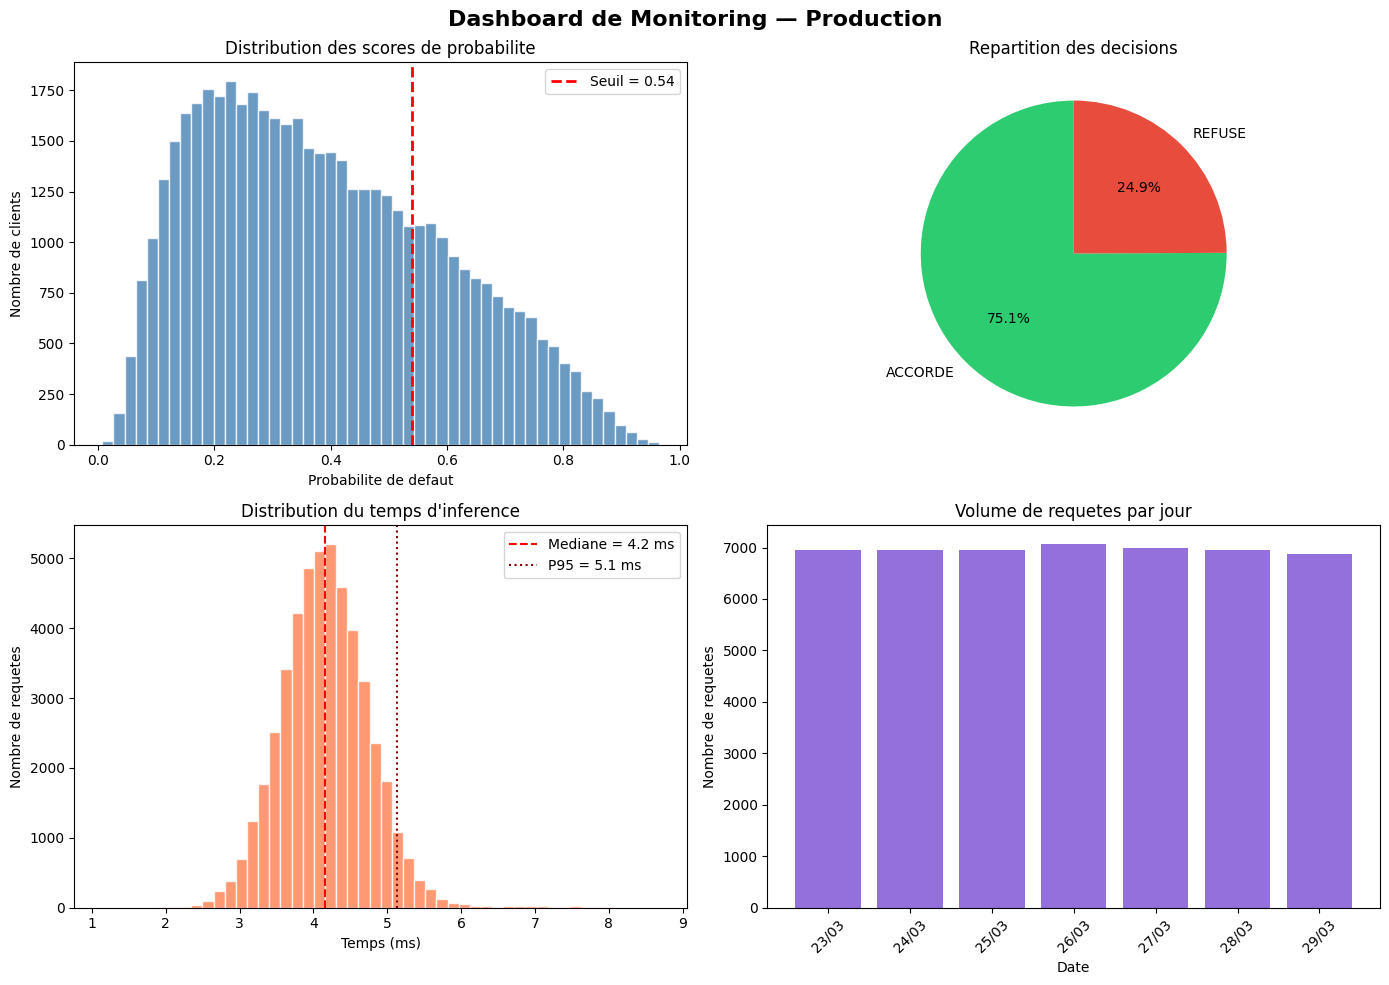


Statistiques de latence :
  Moyenne : 4.16 ms
  Mediane : 4.15 ms
  P95     : 5.13 ms
  P99     : 5.65 ms


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribution des scores
axes[0, 0].hist(df_logs['probability'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0, 0].axvline(THRESHOLD, color='red', linestyle='--', linewidth=2, label=f'Seuil = {THRESHOLD:.2f}')
axes[0, 0].set_title('Distribution des scores de probabilite')
axes[0, 0].set_xlabel('Probabilite de defaut')
axes[0, 0].set_ylabel('Nombre de clients')
axes[0, 0].legend()

# 2. Repartition des decisions
decision_counts = df_logs['decision'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0, 1].pie(decision_counts.values, labels=decision_counts.index, 
               autopct='%1.1f%%', colors=colors, startangle=90)
axes[0, 1].set_title('Repartition des decisions')

# 3. Distribution de la latence
axes[1, 0].hist(df_logs['inference_time_ms'], bins=50, color='coral', edgecolor='white', alpha=0.8)
axes[1, 0].axvline(df_logs['inference_time_ms'].median(), color='red', linestyle='--', 
                    label=f"Mediane = {df_logs['inference_time_ms'].median():.1f} ms")
axes[1, 0].axvline(df_logs['inference_time_ms'].quantile(0.95), color='darkred', linestyle=':', 
                    label=f"P95 = {df_logs['inference_time_ms'].quantile(0.95):.1f} ms")
axes[1, 0].set_title("Distribution du temps d'inference")
axes[1, 0].set_xlabel('Temps (ms)')
axes[1, 0].set_ylabel('Nombre de requetes')
axes[1, 0].legend()

# 4. Volume de requetes par jour
df_logs_sorted = df_logs.sort_values('timestamp')
daily_counts = df_logs_sorted.set_index('timestamp').resample('D').size()
axes[1, 1].bar(daily_counts.index.strftime('%d/%m'), daily_counts.values, color='mediumpurple')
axes[1, 1].set_title('Volume de requetes par jour')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Nombre de requetes')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.suptitle('Dashboard de Monitoring — Production', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../captures/monitoring_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nStatistiques de latence :")
print(f"  Moyenne : {df_logs['inference_time_ms'].mean():.2f} ms")
print(f"  Mediane : {df_logs['inference_time_ms'].median():.2f} ms")
print(f"  P95     : {df_logs['inference_time_ms'].quantile(0.95):.2f} ms")
print(f"  P99     : {df_logs['inference_time_ms'].quantile(0.99):.2f} ms")

## 3. Détection de Data Drift avec Evidently AI

### Qu'est-ce que le data drift ?

Le **data drift** survient quand la distribution des données en production diverge 
de celle des données d'entraînement. Cela peut dégrader les performances du modèle 
sans que les métriques de base (AUC, accuracy) ne le détectent immédiatement.

### Approche
- **Référence** : échantillon du jeu d'entraînement (`reference_data.csv`)
- **Production** : données du test set scorées par le modèle
- **Test statistique** : Kolmogorov-Smirnov pour les variables numériques, chi² pour les catégorielles

In [5]:
from evidently import Report
from evidently.presets import DataDriftPreset, DataSummaryPreset

# Donnees de reference (echantillon du train)
df_reference = pd.read_csv('../data/reference_data.csv')

# Donnees de production (test set sans SK_ID_CURR)
df_production = df_test.drop(columns=['SK_ID_CURR'])

# Les colonnes doivent correspondre
common_cols = [c for c in df_reference.columns if c in df_production.columns]
df_reference = df_reference[common_cols]
df_production = df_production[common_cols]

print(f"Reference : {df_reference.shape}")
print(f"Production : {df_production.shape}")
print(f"Colonnes communes : {len(common_cols)}")

Reference : (5000, 243)
Production : (48744, 243)
Colonnes communes : 243


### 3.1 Rapport de Data Drift (sans drift artificiel)

On compare les distributions entre les données d'entraînement et de production 
**sans modification**. Normalement, le drift devrait être faible puisque les données 
proviennent de la même source.

In [6]:
# Rapport de drift sans perturbation
# On force le test KS (Kolmogorov-Smirnov) pour les variables numeriques
# Par defaut Evidently v0.7 utilise la distance de Wasserstein, qui n'est pas une p-value
drift_report = Report([DataDriftPreset(num_method='ks')])
snapshot = drift_report.run(
    reference_data=df_reference, 
    current_data=df_production.sample(5000, random_state=42)
)

# Sauvegarder le rapport HTML
os.makedirs('../reports', exist_ok=True)
snapshot.save_html('../reports/data_drift_report_no_drift.html')
print("Rapport sauvegarde : ../reports/data_drift_report_no_drift.html")

# Extraire les resultats
metrics = snapshot.dict()['metrics']

# Nombre de features driftees selon Evidently
drifted_count_metric = [m for m in metrics if 'DriftedColumnsCount' in m['metric_name']][0]
n_drifted = int(drifted_count_metric['value']['count'])
share_drifted = drifted_count_metric['value']['share']

drift_metrics = [m for m in metrics if 'ValueDrift' in m['metric_name']]

print(f"\nEvidently detecte {n_drifted} features avec drift sur {len(drift_metrics)} ({share_drifted:.2%})")
print(f"(Test utilise : Kolmogorov-Smirnov, seuil p-value < 0.05)")

Rapport sauvegarde : ../reports/data_drift_report_no_drift.html

Evidently detecte 34 features avec drift sur 243 (13.99%)
(Test utilise : Kolmogorov-Smirnov, seuil p-value < 0.05)


### Focus sur les top features SHAP

Analyser le drift sur les 243 features est bruyant : les features binaires (FLAG_*, ORGANIZATION_TYPE_*) 
polluent le rapport avec des faux positifs. On se concentre sur les **features les plus impactantes** 
selon l'analyse SHAP du notebook 05.

In [7]:
# Top features par importance SHAP (issues du notebook 05)
top_shap_features = [
    'EXT_SOURCE_3', 'EXT_SOURCE_2', 'EXT_SOURCE_1',
    'AMT_CREDIT', 'DAYS_EMPLOYED', 'AMT_ANNUITY',
    'AMT_GOODS_PRICE', 'AMT_INCOME_TOTAL', 'DAYS_BIRTH',
    'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'DAYS_LAST_PHONE_CHANGE',
    'BUREAU_CREDIT_SUM_MAX', 'BUREAU_DAYS_CREDIT_MEAN',
    'CC_UTILIZATION_MEAN', 'PREV_AMT_ANNUITY_MEAN',
    'INSTALL_DAYS_LATE_MAX', 'INSTALL_PAYMENT_DIFF_MEAN',
    'POS_DPD_MAX', 'REGION_POPULATION_RELATIVE',
]

# Filtrer pour ne garder que les colonnes presentes
top_features = [f for f in top_shap_features if f in df_reference.columns]

# Rapport de drift sur les top features uniquement (methode KS)
drift_report_top = Report([DataDriftPreset(columns=top_features, num_method='ks')])
snapshot_top = drift_report_top.run(
    reference_data=df_reference,
    current_data=df_production.sample(5000, random_state=42)
)

snapshot_top.save_html('../reports/data_drift_top_features.html')

# Resultats
metrics_top = snapshot_top.dict()['metrics']
drift_top = [m for m in metrics_top if 'ValueDrift' in m['metric_name']]

print(f"Drift sur les {len(top_features)} top features SHAP (sans perturbation) :")
print(f"{'Feature':<30} {'p-value':>12} {'Drift ?':>10}")
print("-" * 55)
for m in sorted(drift_top, key=lambda x: x['value']):
    col = m['config']['column']
    pval = m['value']
    drifted = "OUI" if pval < 0.05 else "non"
    print(f"{col:<30} {pval:>12.6f} {drifted:>10}")

Drift sur les 20 top features SHAP (sans perturbation) :
Feature                             p-value    Drift ?
-------------------------------------------------------
AMT_CREDIT                         0.000000        OUI
AMT_GOODS_PRICE                    0.000000        OUI
PREV_AMT_ANNUITY_MEAN              0.000000        OUI
DAYS_LAST_PHONE_CHANGE             0.000000        OUI
DAYS_ID_PUBLISH                    0.000000        OUI
AMT_INCOME_TOTAL                   0.000000        OUI
EXT_SOURCE_1                       0.000000        OUI
AMT_ANNUITY                        0.000000        OUI
DAYS_EMPLOYED                      0.000193        OUI
EXT_SOURCE_3                       0.000249        OUI
BUREAU_CREDIT_SUM_MAX              0.003294        OUI
CC_UTILIZATION_MEAN                0.003537        OUI
DAYS_BIRTH                         0.005385        OUI
INSTALL_PAYMENT_DIFF_MEAN          0.005385        OUI
EXT_SOURCE_2                       0.009842        OUI
BUREAU_

### 3.2 Simulation de drift contrôlé

Pour démontrer la capacité de détection, on introduit un **drift artificiel** 
en perturbant certaines features clés :
- `AMT_INCOME_TOTAL` : revenus multipliés par 1.5 (inflation salariale)
- `DAYS_BIRTH` : clients plus jeunes (-2000 jours)
- `EXT_SOURCE_1/2/3` : scores externes dégradés (-0.2)

Ce scénario simule un changement de population de clients demandant un crédit.

In [8]:
# Creer un dataset avec drift artificiel
df_drifted = df_production.sample(5000, random_state=42).copy()

# Perturber les features cles
if 'AMT_INCOME_TOTAL' in df_drifted.columns:
    df_drifted['AMT_INCOME_TOTAL'] *= 1.5  # Inflation salariale

if 'DAYS_BIRTH' in df_drifted.columns:
    df_drifted['DAYS_BIRTH'] += 2000  # Clients plus jeunes

for col in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']:
    if col in df_drifted.columns:
        df_drifted[col] = (df_drifted[col] - 0.2).clip(0, 1)  # Scores degrades

print("Features perturbees :")
for col in ['AMT_INCOME_TOTAL', 'DAYS_BIRTH', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']:
    if col in df_drifted.columns:
        ref_mean = df_reference[col].mean()
        drift_mean = df_drifted[col].mean()
        print(f"  {col}: ref={ref_mean:.2f} → drift={drift_mean:.2f}")

Features perturbees :
  AMT_INCOME_TOTAL: ref=169422.67 → drift=269380.36
  DAYS_BIRTH: ref=-15986.15 → drift=-14161.23
  EXT_SOURCE_1: ref=0.50 → drift=0.31
  EXT_SOURCE_2: ref=0.51 → drift=0.32
  EXT_SOURCE_3: ref=0.51 → drift=0.31


In [9]:
# Rapport de drift avec perturbation — focus top features (methode KS)
drift_report_drifted = Report([DataDriftPreset(columns=top_features, num_method='ks')])
snapshot_drifted = drift_report_drifted.run(
    reference_data=df_reference, 
    current_data=df_drifted[df_reference.columns]
)

snapshot_drifted.save_html('../reports/data_drift_report_with_drift.html')
print("Rapport sauvegarde : ../reports/data_drift_report_with_drift.html")

# Resultats
metrics_d = snapshot_drifted.dict()['metrics']
drift_top_d = [m for m in metrics_d if 'ValueDrift' in m['metric_name']]

print(f"\nDrift sur les {len(top_features)} top features SHAP (avec drift artificiel) :")
print(f"{'Feature':<30} {'p-value':>12} {'Drift ?':>10}")
print("-" * 55)
for m in sorted(drift_top_d, key=lambda x: x['value']):
    col = m['config']['column']
    pval = m['value']
    drifted = "OUI" if pval < 0.05 else "non"
    marker = " << PERTURBEE" if col in ['AMT_INCOME_TOTAL', 'DAYS_BIRTH', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3'] else ""
    print(f"{col:<30} {pval:>12.6f} {drifted:>10}{marker}")

Rapport sauvegarde : ../reports/data_drift_report_with_drift.html

Drift sur les 20 top features SHAP (avec drift artificiel) :
Feature                             p-value    Drift ?
-------------------------------------------------------
EXT_SOURCE_3                       0.000000        OUI << PERTURBEE
EXT_SOURCE_2                       0.000000        OUI << PERTURBEE
EXT_SOURCE_1                       0.000000        OUI << PERTURBEE
AMT_INCOME_TOTAL                   0.000000        OUI << PERTURBEE
DAYS_BIRTH                         0.000000        OUI << PERTURBEE
AMT_CREDIT                         0.000000        OUI
AMT_GOODS_PRICE                    0.000000        OUI
PREV_AMT_ANNUITY_MEAN              0.000000        OUI
DAYS_LAST_PHONE_CHANGE             0.000000        OUI
DAYS_ID_PUBLISH                    0.000000        OUI
AMT_ANNUITY                        0.000000        OUI
DAYS_EMPLOYED                      0.000193        OUI
BUREAU_CREDIT_SUM_MAX              0

### 3.3 Comparaison visuelle : avec et sans drift

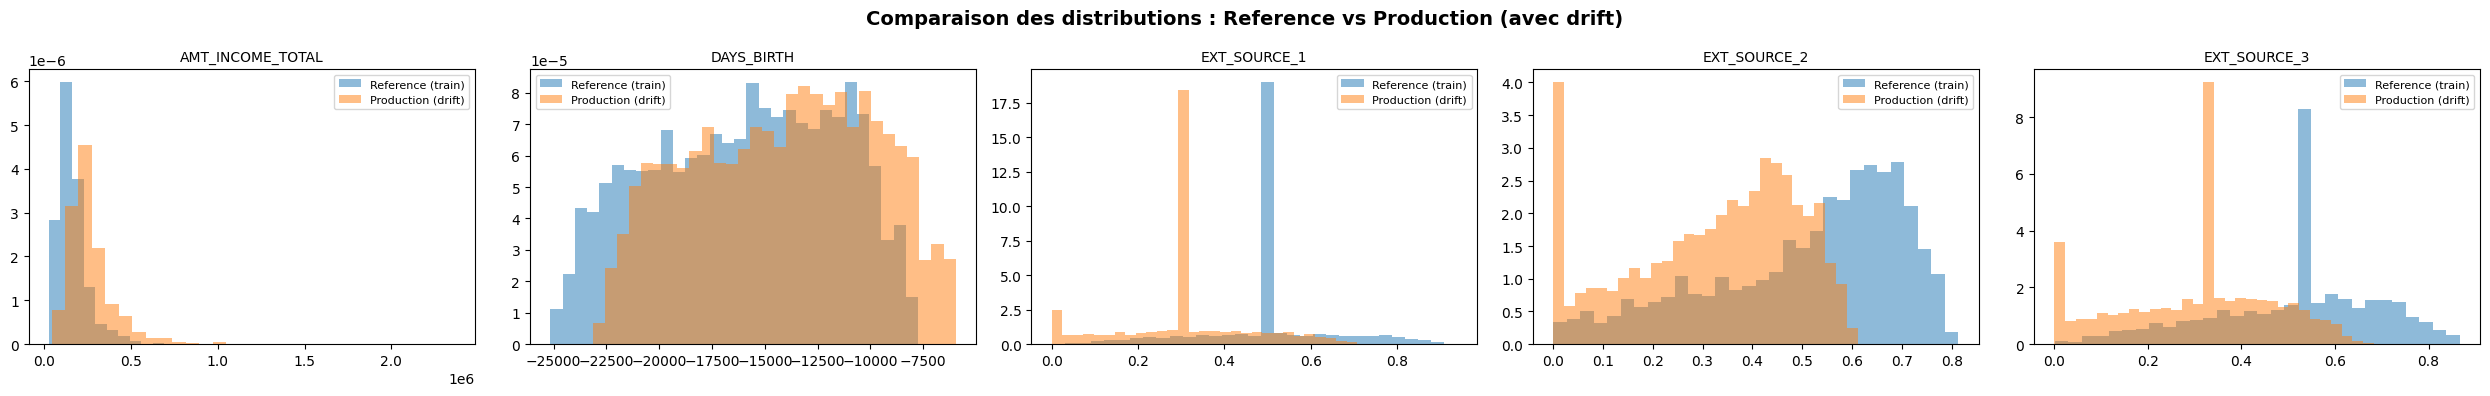

In [10]:
# Visualiser le drift sur les features cles
drift_features = ['AMT_INCOME_TOTAL', 'DAYS_BIRTH', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
drift_features = [f for f in drift_features if f in df_reference.columns]

fig, axes = plt.subplots(1, len(drift_features), figsize=(5 * len(drift_features), 4))

for i, col in enumerate(drift_features):
    ax = axes[i] if len(drift_features) > 1 else axes
    ax.hist(df_reference[col].dropna(), bins=30, alpha=0.5, label='Reference (train)', density=True)
    ax.hist(df_drifted[col].dropna(), bins=30, alpha=0.5, label='Production (drift)', density=True)
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('Comparaison des distributions : Reference vs Production (avec drift)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../captures/drift_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Rapport de qualité des données

In [11]:
# Rapport de qualite des donnees de production
quality_report = Report([DataSummaryPreset()])
snapshot_quality = quality_report.run(
    reference_data=df_reference, 
    current_data=df_production.sample(5000, random_state=42)
)

snapshot_quality.save_html('../reports/data_quality_report.html')
print("Rapport de qualite sauvegarde : ../reports/data_quality_report.html")
print("Ouvrir ce fichier HTML dans un navigateur pour voir les statistiques detaillees.")

Rapport de qualite sauvegarde : ../reports/data_quality_report.html
Ouvrir ce fichier HTML dans un navigateur pour voir les statistiques detaillees.


## 5. Conclusions et points de vigilance

### Résultats du monitoring

**Sans drift artificiel :**
- Le test KS détecte un drift significatif (p-value < 0.05) sur 15 des 20 top features SHAP, et sur ~14% de l'ensemble des 243 features.
- Cela ne signifie pas forcément un problème grave : avec des échantillons de grande taille (5000+ lignes), le test KS est très **sensible** et détecte des écarts minimes entre train et test, même quand les distributions sont visuellement proches.
- Evidently ne déclare pas de drift au niveau du dataset entier (seuil : drift_share > 50%).

**Avec drift artificiel :**
- Les 5 features perturbées (EXT_SOURCE_1/2/3, AMT_INCOME_TOTAL, DAYS_BIRTH) remontent **en tête du classement** avec des p-values quasi nulles.
- Le test KS détecte correctement le drift artificiel sur les features qui comptent le plus pour le modèle.
- Les features non perturbées conservent les mêmes p-values → le test est stable et fiable.

### Leçons apprises

1. **Le choix de la méthode compte** : Evidently v0.7 utilise par défaut la distance de Wasserstein (un score de distance), pas le test KS (une p-value). Il faut spécifier `num_method='ks'` pour obtenir des p-values interprétables.
2. **La taille de l'échantillon compte** : plus les échantillons sont grands, plus le test KS est sensible. Un drift statistiquement significatif n'est pas forcément significatif en pratique.
3. **Filtrer sur les features critiques** : analyser les 243 features noie l'information. Le focus sur les top 20 SHAP donne des résultats actionnables.

### Points de vigilance en production

| Risque | Feature(s) concernée(s) | Action recommandée |
|--------|------------------------|-------------------|
| **Drift des scores externes** | EXT_SOURCE_1/2/3 | Monitorer en priorité — top 3 SHAP |
| **Changement de population** | DAYS_BIRTH, AMT_INCOME_TOTAL | Alerter si la distribution change |
| **Latence anormale** | inference_time_ms | Alerter si P95 > 100ms (actuellement ~5ms) |
| **Taux de refus anormal** | decision | Alerter si ratio REFUSÉ dépasse 30% (actuellement ~25%) |

### Recommandations
- Exécuter le rapport Evidently **hebdomadairement** sur les dernières prédictions
- **Filtrer le rapport** sur les top 20 features SHAP pour éviter le bruit
- Planifier un **ré-entraînement** si un drift est confirmé sur les EXT_SOURCE ou si l'AUC chute
- Conserver les logs de prédiction pour analyse rétrospective